In [2]:
import os.path
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import keras
import librosa
import librosa.feature
from keras import Sequential
from keras.src.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, GlobalAveragePooling2D
from keras.src.utils import audio_dataset_from_directory, to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import sounddevice as sd
import tkinter as tk
from tkinter import ttk
import threading
import time


In [3]:
SAMPLE_RATE = 22050
DURATION = 5
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128

In [4]:
metadata = pd.read_csv('data/ESC-50-master/meta/esc50.csv')

In [5]:
def load_audio(path: str, sr=SAMPLE_RATE, duration=DURATION):
    audio, src = librosa.load(path, sr=SAMPLE_RATE, duration=DURATION)
    return audio


In [6]:
def extract_stft_features(audio, n_fft, hop_length,n_mels):
    stft = librosa.feature.melspectrogram(y=audio, n_fft=n_fft, hop_length=hop_length,n_mels=n_mels)
    # magnitude = np.abs(stft)
    stft_db = librosa.power_to_db(stft, ref=np.max)
    stft_db = stft_db[..., np.newaxis]
    return stft_db

In [7]:
def load_dataset():
    features = []
    labels = []

    for index, row in tqdm(metadata.iterrows(), total=len(metadata)):
        file_name = row['filename']
        category = row['category']

        audio = os.path.join('data/ESC-50-master/audio/', file_name)
        audio = load_audio(audio, SAMPLE_RATE, DURATION)
        if audio is not None:
            stft = extract_stft_features(audio, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
            features.append(stft)
            labels.append(category)
    features = np.array(features)
    labels = np.array(labels)

    return features, labels

In [8]:
features, labels = load_dataset()

  0%|          | 0/2000 [00:00<?, ?it/s]C:\Users\abol\PycharmProjects\SpeechRecognizeCNN\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 2000/2000 [00:20<00:00, 98.68it/s] 


In [9]:
print(features.shape)
print(features.dtype)

print("min:", features.min())
print("max:", features.max())
print("mean:", features.mean())
print("std:", features.std())


(2000, 128, 216, 1)
float32
min: -80.0
max: 0.0
mean: -48.913292
std: 20.705288


In [9]:
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)


In [11]:
# print(labels_encoded.shape)
# print(np.unique(labels_encoded))
# print(np.bincount(labels_encoded))
# print(labels.shape)
# print(labels[0])
# print(labels[0].sum())
#
# for i in range(10):
#     print(
#         metadata.iloc[i]["filename"],
#         metadata.iloc[i]["category"],
#         labels_encoded[i],
#         label_encoder.inverse_transform([labels_encoded[i]])[0]
#     )

In [12]:
test_mask = metadata['fold'].values == 1
train_mask = metadata['fold'].values != 1
x_train = features[train_mask]
x_test = features[test_mask]
y_train = labels_encoded[train_mask]
y_test = labels_encoded[test_mask]

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

print(metadata[["filename", "fold", "category"]].head(20))
print(metadata["fold"].value_counts())


(1600, 128, 216, 1) (1600, 50)
(400, 128, 216, 1) (400, 50)
             filename  fold         category
0    1-100032-A-0.wav     1              dog
1   1-100038-A-14.wav     1   chirping_birds
2   1-100210-A-36.wav     1   vacuum_cleaner
3   1-100210-B-36.wav     1   vacuum_cleaner
4   1-101296-A-19.wav     1     thunderstorm
5   1-101296-B-19.wav     1     thunderstorm
6   1-101336-A-30.wav     1  door_wood_knock
7   1-101404-A-34.wav     1      can_opening
8    1-103298-A-9.wav     1             crow
9   1-103995-A-30.wav     1  door_wood_knock
10  1-103999-A-30.wav     1  door_wood_knock
11  1-104089-A-22.wav     1         clapping
12  1-104089-B-22.wav     1         clapping
13  1-105224-A-22.wav     1         clapping
14   1-110389-A-0.wav     1              dog
15  1-110537-A-22.wav     1         clapping
16  1-115521-A-19.wav     1     thunderstorm
17  1-115545-A-48.wav     1        fireworks
18  1-115545-B-48.wav     1        fireworks
19  1-115545-C-48.wav     1        firew

In [ ]:
plt.figure(figsize=(10, 4))

librosa.display.specshow(
    x_test[2][:, :, -1],
    sr=SAMPLE_RATE,
    hop_length=HOP_LENGTH,
    x_axis='time',
    y_axis='mel',
    cmap=plt.cm.hsv,
)

plt.colorbar(format='%+2.0f dB')
plt.show()

In [14]:
model = Sequential([

    Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(N_MELS, 216, 1)
    ),

    Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    MaxPooling2D((2, 2)),

    Dropout(0.25),

    Conv2D(
        128,
        (3, 3),
        activation='relu'
    ),

    MaxPooling2D((2, 2)),

    Dropout(0.25),

    GlobalAveragePooling2D(),

    Dense(64, activation='relu'),

    Dropout(0.3),

    Dense(50, activation='softmax')
])

C:\Users\abol\PycharmProjects\SpeechRecognizeCNN\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(x_train.dtype)
print(y_train.dtype)

print(x_train.shape)
print(y_train.shape)

float32
float32
(1600, 128, 216, 1)
(1600, 50)


In [19]:
history = model.fit(
    x_train,
    y_train,
    epochs=100,
    batch_size=16,
    verbose=1,
    validation_data=(x_test, y_test),
)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 90s 890ms/step - accuracy: 0.0175 - loss: 3.9179 - val_accuracy: 0.0350 - val_loss: 3.8733
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 70s 697ms/step - accuracy: 0.0344 - loss: 3.8328 - val_accuracy: 0.0425 - val_loss: 3.7211
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 59s 593ms/step - accuracy: 0.0456 - loss: 3.6799 - val_accuracy: 0.0800 - val_loss: 3.5481
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 59s 594ms/step - accuracy: 0.0637 - loss: 3.5543 - val_accuracy: 0.0775 - val_loss: 3.5162
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 60s 598ms/step - accuracy: 0.0938 - loss: 3.4292 - val_accuracy: 0.1200 - val_loss: 3.3191
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 60s 604ms/step - accuracy: 0.1063 - loss: 3.3144 - val_accuracy: 0.1500 - val_loss: 3.1113
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 61s 610ms/step - accuracy: 0.1175 - loss: 3.1448 - val_accuracy: 0.1725 - val_loss: 2.9403
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 60s 600ms/step - accuracy: 0.1356 -

In [58]:
selected_classes = [0, 1, 2, 3, 4]

mask = np.isin(labels_encoded, selected_classes)

x_debug = features[mask]
y_debug = labels_encoded[mask]

y_debug = to_categorical(
    y_debug,
    num_classes=50
)

model.fit(
    x_debug,
    y_debug,
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 584ms/step - accuracy: 0.0100 - loss: 4.7262
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 553ms/step - accuracy: 0.1400 - loss: 3.1265
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 899ms/step - accuracy: 0.2900 - loss: 2.2395
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 711ms/step - accuracy: 0.4500 - loss: 1.5895
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 555ms/step - accuracy: 0.5100 - loss: 1.2309
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 590ms/step - accuracy: 0.5650 - loss: 1.1648
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 584ms/step - accuracy: 0.5550 - loss: 1.1044
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 548ms/step - accuracy: 0.5900 - loss: 1.0361
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 547ms/step - accuracy: 0.6650 - loss: 0.8324
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 571ms/step - accuracy: 0.6650 - loss: 0.8243
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 589ms/step - accuracy: 0.6650 - loss: 0.8320
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━

KeyboardInterrupt: 

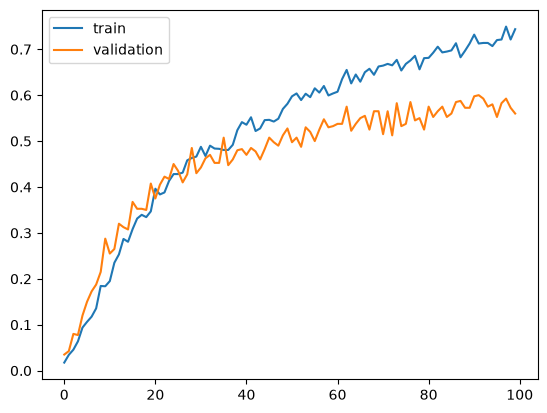

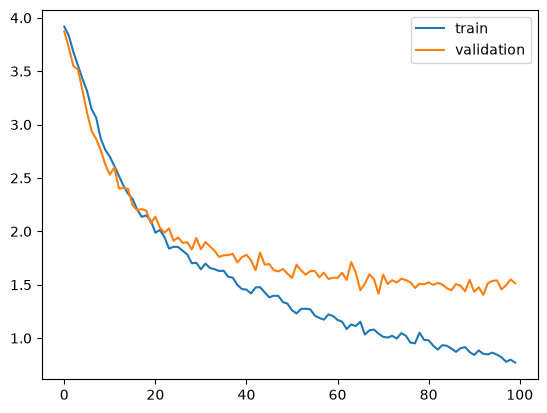

In [21]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.legend()
plt.show()

In [20]:
model.save('model.keras')

In [10]:
model = keras.models.load_model('model.keras')

In [14]:
print("Recording...")

audio = sd.rec(
    int(DURATION * SAMPLE_RATE),
    samplerate=SAMPLE_RATE,
    channels=1,
    dtype="float32"
)

sd.wait()

print("Recording finished!")

# حذف channel
audio = audio.flatten()

# Mel Spectrogram
mel_db = extract_stft_features(audio, n_fft=N_FFT, hop_length=HOP_LENGTH,n_mels=N_MELS)

# اضافه کردن batch dimension
test = np.expand_dims(mel_db, axis=0)

print("Model input:", test.shape)



Recording...
Recording finished!
Model input: (1, 128, 216, 1)


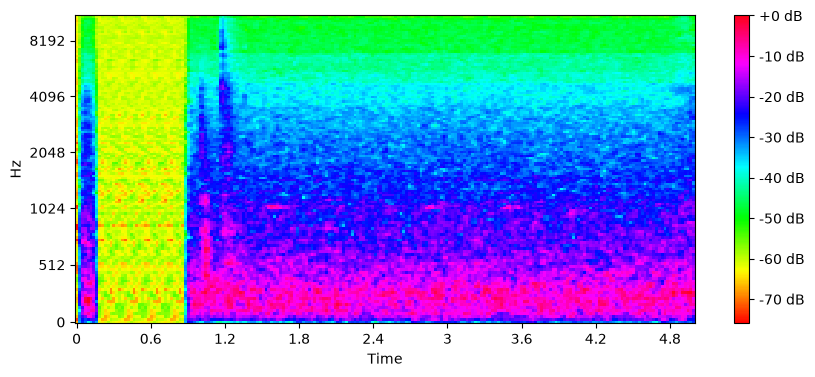

In [15]:
plt.figure(figsize=(10, 4))

librosa.display.specshow(
    test.squeeze(),
    sr=SAMPLE_RATE,
    hop_length=HOP_LENGTH,
    n_fft=N_FFT,
    x_axis='time',
    y_axis='mel',
    cmap=plt.cm.hsv,
)

plt.colorbar(format='%+2.0f dB')
plt.show()

In [16]:
result = model.predict(test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


thunderstorm: 38.01%
fireworks: 31.47%
train: 6.35%
sea_waves: 4.36%
breathing: 3.07%


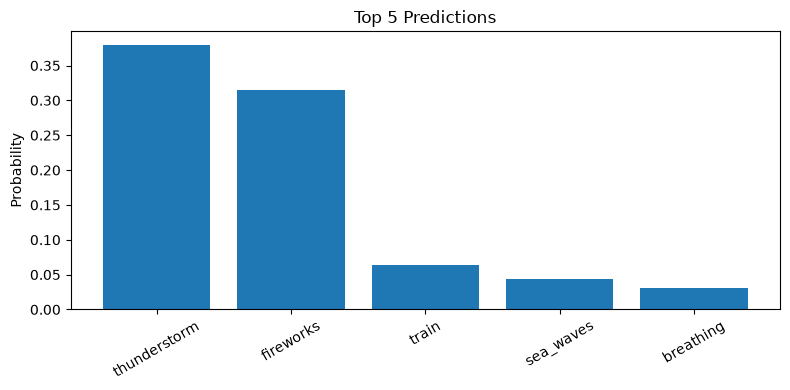

In [17]:
classes = label_encoder.classes_

probabilities = result[0]

top_indices = np.argsort(probabilities)[-5:][::-1]

for i in top_indices:
    print(
        f"{label_encoder.classes_[i]}: "
        f"{probabilities[i] * 100:.2f}%"
    )

top_classes = classes[top_indices]
top_probs = probabilities[top_indices]

plt.figure(figsize=(8, 4))
plt.bar(top_classes, top_probs)

plt.ylabel("Probability")
plt.title("Top 5 Predictions")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# LIVE AUDIO CONFIG
# ============================================================

BLOCK_SIZE = 1024
PREDICTION_INTERVAL = 0.5

audio_buffer = np.zeros(
    int(SAMPLE_RATE * DURATION),
    dtype=np.float32
)

buffer_lock = threading.Lock()

running = False
audio_stream = None
prediction_thread = None

In [12]:
def audio_callback(indata, frames, time_info, status):
    if status:
        print(status)

    if not running:
        return

    audio = indata[:, 0].copy()

    with buffer_lock:

        global audio_buffer

        # حذف صدای قدیمی
        audio_buffer[:-len(audio)] = audio_buffer[len(audio):]

        # اضافه کردن صدای جدید
        audio_buffer[-len(audio):] = audio

In [13]:
def predict_audio(audio):
    # ساخت Mel Spectrogram
    mel_db = extract_stft_features(
        audio,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    )

    # mel_db:
    # (128, 216, 1)

    test = np.expand_dims(
        mel_db,
        axis=0
    )

    # test:
    # (1, 128, 216, 1)

    result = model.predict(
        test,
        verbose=0
    )

    probabilities = result[0]

    predicted_index = np.argmax(
        probabilities
    )

    confidence = probabilities[
        predicted_index
    ]

    predicted_class = label_encoder.classes_[
        predicted_index
    ]

    return predicted_class, confidence

In [14]:
def update_prediction_ui(
        predicted_class,
        confidence,
        rms
):
    icon = CLASS_ICONS.get(predicted_class, "🔊")

    prediction_label.config(
       text=f"{icon}  {predicted_class}"
    )

    confidence_label.config(
        text=f"Confidence: {confidence * 100:.1f}%"
    )

    # تبدیل RMS به مقدار مناسب برای Progressbar
    volume = min(
        100,
        rms * 2000
    )

    volume_bar["value"] = volume

In [15]:
def prediction_worker():
    global running

    while running:

        time.sleep(
            PREDICTION_INTERVAL
        )

        if not running:
            break

        # گرفتن آخرین 5 ثانیه
        with buffer_lock:

            audio = audio_buffer.copy()

        # محاسبه RMS برای تشخیص سکوت
        rms = np.sqrt(
            np.mean(
                np.square(audio)
            )
        )

        # اگر صدای خیلی کمی وجود دارد
        if rms < 0.003:
            root.after(
                0,
                update_prediction_ui,
                "Listening...",
                0.0,
                rms
            )

            continue

        try:

            predicted_class, confidence = predict_audio(
                audio
            )

            root.after(
                0,
                update_prediction_ui,
                predicted_class,
                confidence,
                rms
            )

        except Exception as e:

            print(
                "Prediction error:",
                e
            )

In [16]:
def start_listening():
    global running
    global audio_stream
    global prediction_thread
    global audio_buffer

    if running:
        return

    # پاک کردن buffer
    with buffer_lock:

        audio_buffer = np.zeros(
            int(SAMPLE_RATE * DURATION),
            dtype=np.float32
        )

    running = True

    try:

        audio_stream = sd.InputStream(
            samplerate=SAMPLE_RATE,
            channels=1,
            dtype="float32",
            blocksize=BLOCK_SIZE,
            callback=audio_callback
        )

        audio_stream.start()

    except Exception as e:

        running = False

        prediction_label.config(
            text="Microphone Error"
        )

        confidence_label.config(
            text=str(e)
        )

        return

    start_button.config(
        state=tk.DISABLED
    )

    stop_button.config(
        state=tk.NORMAL
    )

    status_label.config(
        text="● Listening...",
        fg="green"
    )

    prediction_thread = threading.Thread(
        target=prediction_worker,
        daemon=True
    )

    prediction_thread.start()

In [17]:
def stop_listening():
    global running
    global audio_stream

    running = False

    if audio_stream is not None:

        try:

            audio_stream.stop()
            audio_stream.close()

        except Exception as e:

            print(e)

        audio_stream = None

    start_button.config(
        state=tk.NORMAL
    )

    stop_button.config(
        state=tk.DISABLED
    )

    status_label.config(
        text="● Stopped",
        fg="red"
    )

    prediction_label.config(
        text="Press Start"
    )

    confidence_label.config(
        text="Confidence: --"
    )

    volume_bar["value"] = 0

In [18]:
def close_app():
    stop_listening()

    root.destroy()

In [19]:
CLASS_ICONS = {
    "dog": "🐶",
    "chirping_birds": "🐦",
    "vacuum_cleaner": "🧹",
    "thunderstorm": "⛈️",
    "door_wood_knock": "🚪",
    "can_opening": "🥫",
    "crow": "🐦‍⬛",
    "clapping": "👏",
    "fireworks": "🎆",
    "chainsaw": "🪚",
    "airplane": "✈️",
    "mouse_click": "🖱️",
    "pouring_water": "💧",
    "train": "🚆",
    "sheep": "🐑",
    "water_drops": "💧",
    "church_bells": "🔔",
    "clock_alarm": "⏰",
    "keyboard_typing": "⌨️",
    "wind": "💨",
    "footsteps": "👣",
    "frog": "🐸",
    "cow": "🐄",
    "brushing_teeth": "🪥",
    "car_horn": "🚗",
    "crackling_fire": "🔥",
    "helicopter": "🚁",
    "drinking_sipping": "🥤",
    "rain": "🌧️",
    "insects": "🐝",
    "laughing": "😂",
    "hen": "🐔",
    "engine": "⚙️",
    "breathing": "😮‍💨",
    "crying_baby": "👶",
    "hand_saw": "🪚",
    "coughing": "😷",
    "glass_breaking": "💥",
    "snoring": "😴",
    "toilet_flush": "🚽",
    "pig": "🐷",
    "washing_machine": "🧺",
    "clock_tick": "⏱️",
    "sneezing": "🤧",
    "rooster": "🐓",
    "sea_waves": "🌊",
    "siren": "🚨",
    "cat": "🐱",
    "door_wood_creaks": "🚪",
    "crickets": "🦗",
}

In [20]:
# ============================================================
# TKINTER UI
# ============================================================

root = tk.Tk()

root.title(
    "ESC-50 Live Audio Classifier"
)

root.geometry(
    "600x650"
)

root.minsize(
    500,
    600
)

# ============================================================
# MAIN FRAME
# ============================================================

main_frame = tk.Frame(
    root,
    padx=40,
    pady=30
)

main_frame.pack(
    fill="both",
    expand=True
)

# ============================================================
# TITLE
# ============================================================

title_label = tk.Label(
    main_frame,
    text="ESC-50 Audio Classifier",
    font=("Arial", 25, "bold")
)

title_label.pack(
    pady=(10, 5)
)

subtitle_label = tk.Label(
    main_frame,
    text="Live CNN Audio Recognition",
    font=("Arial", 12)
)

subtitle_label.pack(
    pady=(0, 25)
)

# ============================================================
# MICROPHONE
# ============================================================

mic_canvas = tk.Canvas(
    main_frame,
    width=180,
    height=180,
    highlightthickness=0
)

mic_canvas.pack(
    pady=10
)

# Outer circle

mic_canvas.create_oval(
    10,
    10,
    170,
    170,
    outline="gray",
    width=3
)

# Microphone

mic_canvas.create_oval(
    75,
    40,
    105,
    115,
    outline="black",
    width=8
)

mic_canvas.create_arc(
    55,
    70,
    125,
    140,
    start=0,
    extent=180,
    style=tk.ARC,
    width=7
)

mic_canvas.create_line(
    90,
    135,
    90,
    150,
    width=7
)

mic_canvas.create_line(
    70,
    155,
    110,
    155,
    width=7
)

# ============================================================
# STATUS
# ============================================================

status_label = tk.Label(
    main_frame,
    text="● Stopped",
    font=("Arial", 13, "bold"),
    fg="red"
)

status_label.pack(
    pady=10
)

# ============================================================
# PREDICTION
# ============================================================

prediction_title = tk.Label(
    main_frame,
    text="Prediction",
    font=("Arial", 12)
)

prediction_title.pack()

prediction_label = tk.Label(
    main_frame,
    text="Press Start",
    font=("Arial", 28, "bold")
)

prediction_label.pack(
    pady=5
)

# ============================================================
# CONFIDENCE
# ============================================================

confidence_label = tk.Label(
    main_frame,
    text="Confidence: --",
    font=("Arial", 14)
)

confidence_label.pack(
    pady=(0, 20)
)

# ============================================================
# VOLUME
# ============================================================

volume_label = tk.Label(
    main_frame,
    text="Microphone level",
    font=("Arial", 11)
)

volume_label.pack()

volume_bar = ttk.Progressbar(
    main_frame,
    orient="horizontal",
    length=400,
    mode="determinate",
    maximum=100
)

volume_bar.pack(
    pady=(5, 25)
)

# ============================================================
# BUTTONS
# ============================================================

button_frame = tk.Frame(
    main_frame
)

button_frame.pack()

start_button = tk.Button(
    button_frame,
    text="🎙 Start Listening",
    command=start_listening,
    font=("Arial", 14, "bold"),
    padx=25,
    pady=12
)

start_button.pack(
    side="left",
    padx=10
)

stop_button = tk.Button(
    button_frame,
    text="■ Stop",
    command=stop_listening,
    font=("Arial", 14, "bold"),
    padx=30,
    pady=12,
    state=tk.DISABLED
)

stop_button.pack(
    side="left",
    padx=10
)

# ============================================================
# INFO
# ============================================================

info_label = tk.Label(
    main_frame,
    text="The model analyzes the latest 5 seconds of audio.",
    font=("Arial", 10)
)

info_label.pack(
    pady=20
)

# ============================================================
# CLOSE
# ============================================================

root.protocol(
    "WM_DELETE_WINDOW",
    close_app
)

# ============================================================
# START UI
# ============================================================

root.mainloop()

In [21]:
metadata['category'].unique()

<StringArray>
[             'dog',   'chirping_birds',   'vacuum_cleaner',
     'thunderstorm',  'door_wood_knock',      'can_opening',
             'crow',         'clapping',        'fireworks',
         'chainsaw',         'airplane',      'mouse_click',
    'pouring_water',            'train',            'sheep',
      'water_drops',     'church_bells',      'clock_alarm',
  'keyboard_typing',             'wind',        'footsteps',
             'frog',              'cow',   'brushing_teeth',
         'car_horn',   'crackling_fire',       'helicopter',
 'drinking_sipping',             'rain',          'insects',
         'laughing',              'hen',           'engine',
        'breathing',      'crying_baby',         'hand_saw',
         'coughing',   'glass_breaking',          'snoring',
     'toilet_flush',              'pig',  'washing_machine',
       'clock_tick',         'sneezing',          'rooster',
        'sea_waves',            'siren',              'cat',
 'door_woo